In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def get_theta(theta_min, theta_max, num_theta):
    ARCMIN_TO_RAD = 2.90888208665721580e-4
    RAD_TO_ARCMIN = 1/ARCMIN_TO_RAD

    THETA_MIN_RAD = theta_min * ARCMIN_TO_RAD
    THETA_MAX_RAD = theta_max * ARCMIN_TO_RAD
    DLOG_THETA = (np.log(THETA_MAX_RAD) - np.log(THETA_MIN_RAD))/num_theta
    theta = np.zeros(num_theta)
    for i in range(num_theta):
        THETA_MIN_BIN = np.exp(np.log(THETA_MIN_RAD) + i * DLOG_THETA)
        THETA_MAX_BIN = np.exp(np.log(THETA_MIN_RAD) + (i + 1) * DLOG_THETA)
        theta[i] = (2/3) * (THETA_MAX_BIN**3 - THETA_MIN_BIN**3) / (THETA_MAX_BIN**2 - THETA_MIN_BIN**2)

    theta *= RAD_TO_ARCMIN
    return theta


In [ ]:
theta = get_theta(2.5, 900, 15) # from data/example1.dataset

In [ ]:
_, dv_baryons   = np.loadtxt("SPK.modelvector", unpack=True)
_, dv_nobaryons = np.loadtxt("DMO.modelvector", unpack=True)

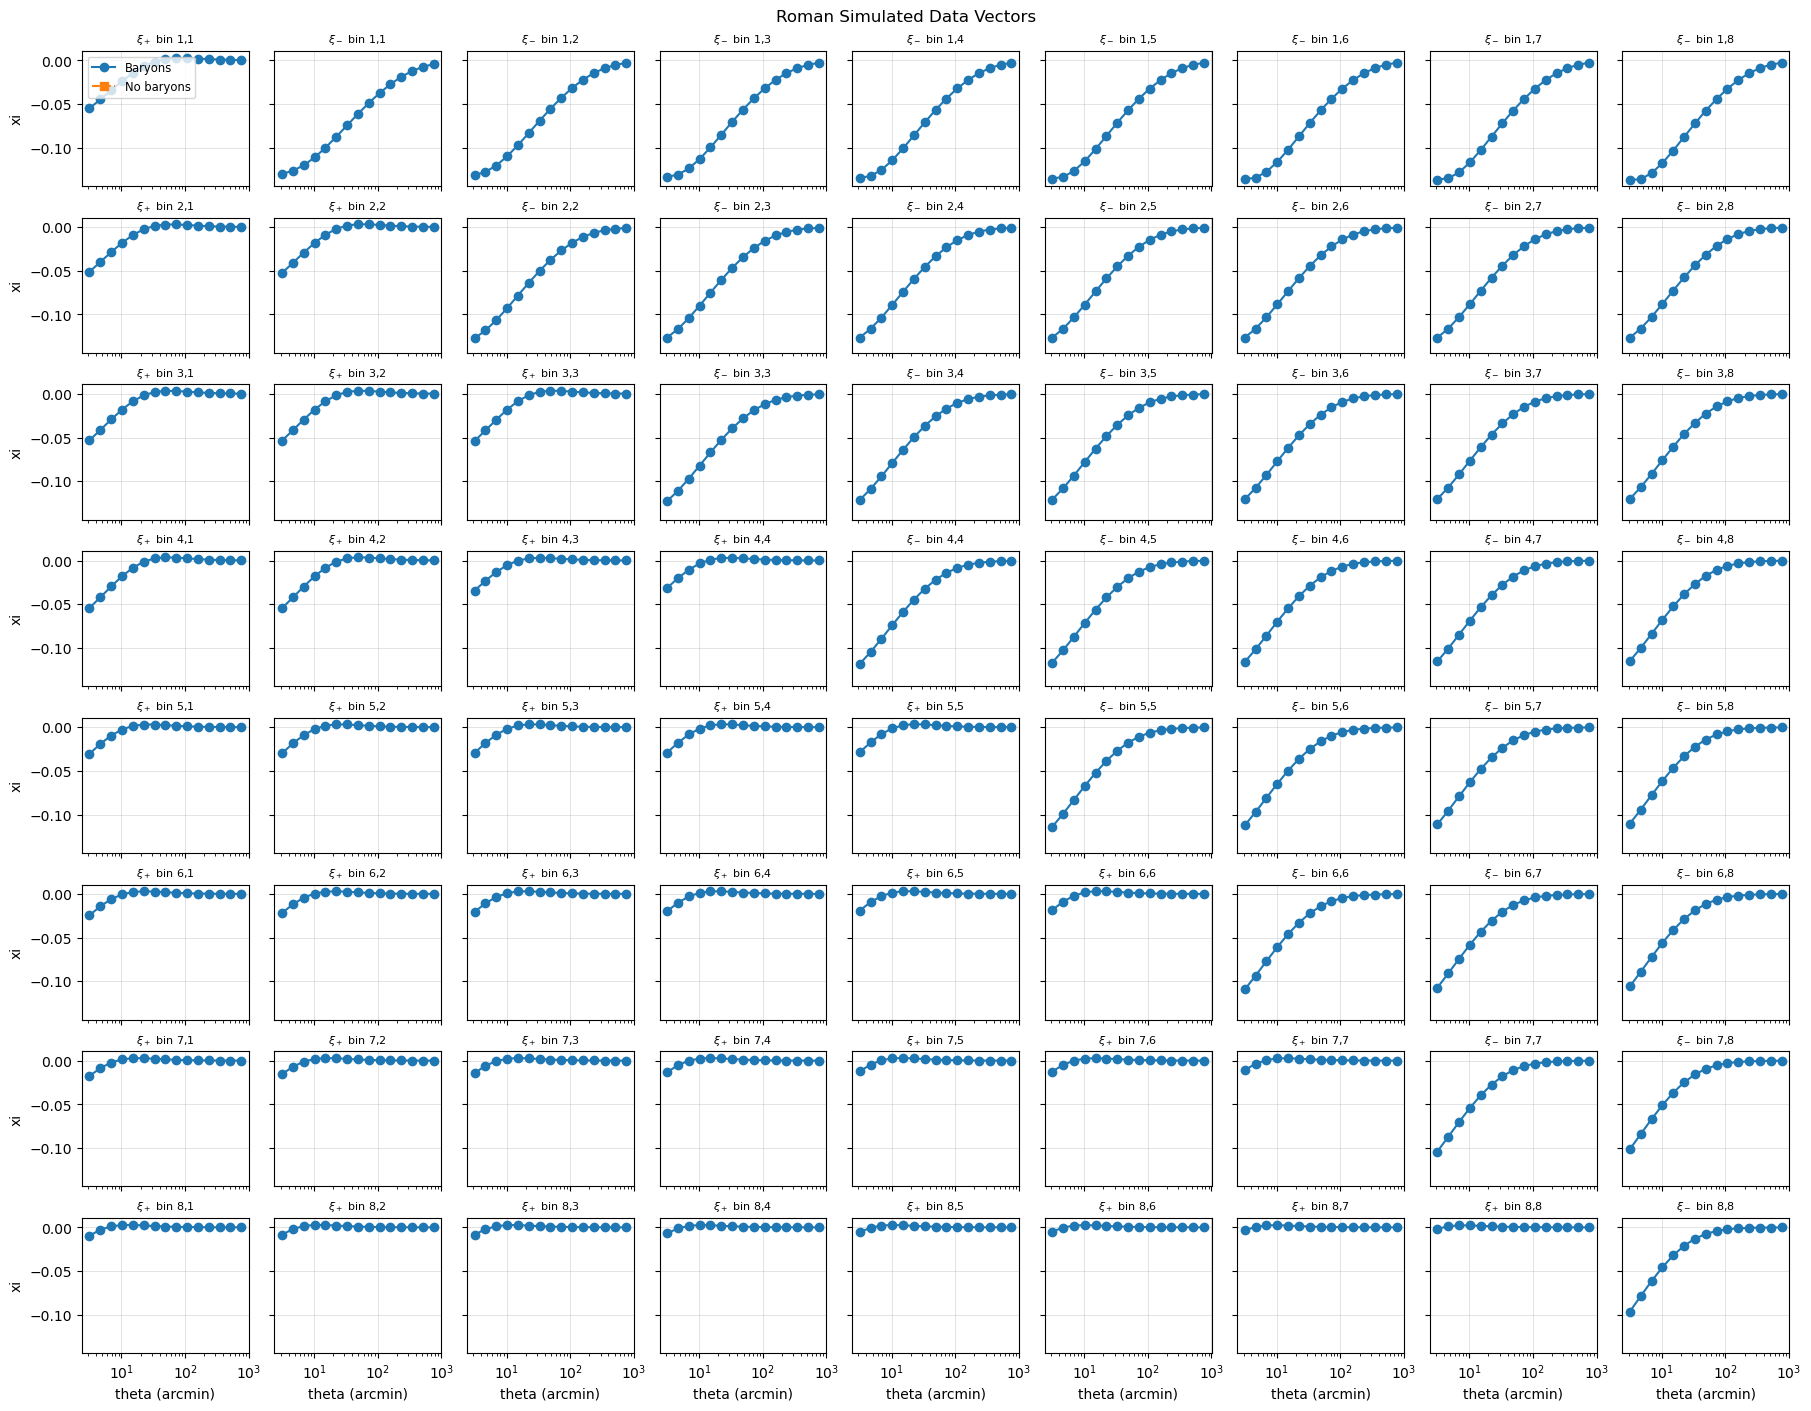

In [ ]:
num_bins = 8
num_cols = num_bins+1
block_size = 15
tri_count = num_bins * (num_bins + 1) // 2

xi_plus_baryons = dv_baryons[:tri_count * block_size]
xi_minus_baryons = dv_baryons[tri_count * block_size:2 * tri_count * block_size]
xi_plus_nobaryons = dv_nobaryons[:tri_count * block_size]
xi_minus_nobaryons = dv_nobaryons[tri_count * block_size:2 * tri_count * block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            ax.semilogx(theta, (xi_plus_baryons[start:end] - xi_plus_nobaryons[start:end])/xi_plus_nobaryons[start:end], color='C0', marker='o', linestyle='-')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size
            ax.semilogx(theta, (xi_minus_baryons[start:end] - xi_minus_nobaryons[start:end])/xi_minus_nobaryons[start:end], color='C0', marker='o', linestyle='-')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        if i == num_bins - 1:
            ax.set_xlabel('theta (arcmin)')
        if col == 0:
            ax.set_ylabel('$(\\xi^\\mathrm{SPK} - \\xi^\\mathrm{DMO}) / \\xi^\\mathrm{DMO}$')

        ax.set_title(f'{label} bin {i+1},{j+1}', fontsize=8)
        ax.grid(True, linewidth=0.5, alpha=0.5)

fig.suptitle('Roman Simulated Data Vectors: Relative difference between SPK and DMO')
plt.show()